In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec
from tabulate import tabulate

from hbn.constants import Defaults  

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [16]:
# load data

df = pd.read_csv(os.path.join(Defaults.INTERIM_DIR, 'phenotypes', 'participant_train_test.csv'), engine='python')

# remove No Diagnosis Given: Incomplete data
drop_participants = df[df['DX_Cat_Name'].str.contains('No Diagnosis Given: Incomplete Eval').fillna(False)]['Identifiers']

df_filter = df[~df['Identifiers'].isin(drop_participants)]

# df_filter['DX_Cat_Name'] = df_filter['DX_Cat_Name'].map({'Specific Learning Disorder with Impairment in Reading': 'Reading Impairment'})
df_filter['DX_Cat_Name'] = df_filter['DX_Cat_Name'].str.replace('Specific Learning Disorder with Impairment in Reading', 'Reading Impairment')

# new column: Diagnosis, True or False
df_filter['Diagnosis'] = df_filter['DX_Cat_Name'].apply(lambda x: x if x in ['No Diagnosis Given', 'Reading Impairment'] else float("NaN"))


<Figure size 640x480 with 0 Axes>

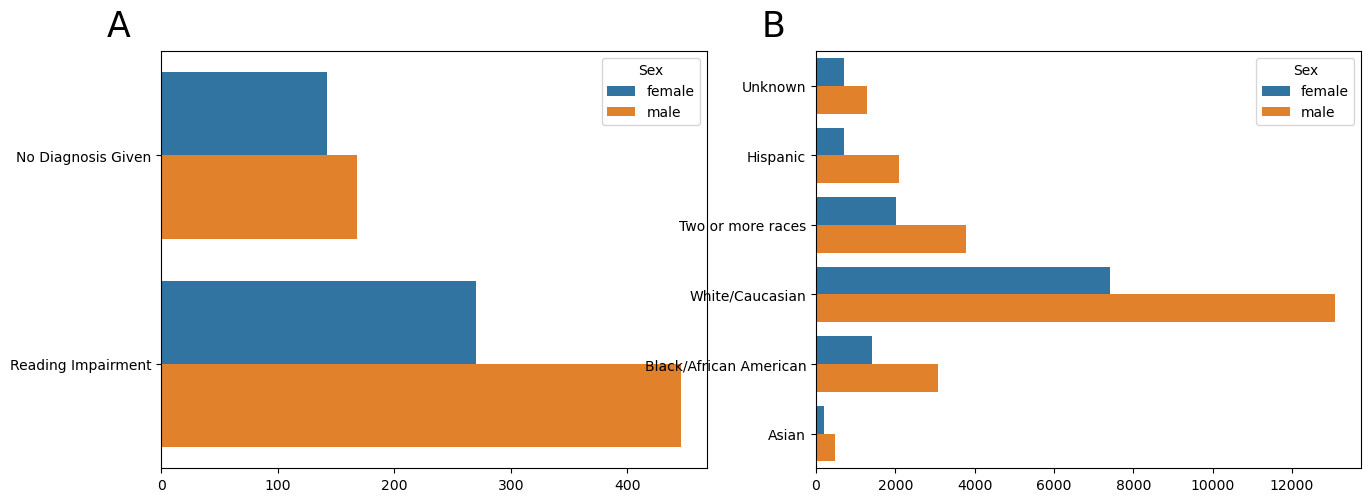

In [21]:
plt.clf()
#plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 25

fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

ax = fig.add_subplot(gs[0,0])
sns.countplot(data=df_filter, y='Diagnosis', hue='Sex', ax=ax)
ax.set_ylabel('')
ax.set_xlabel('')
# ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title('Sex')

ax = fig.add_subplot(gs[0,1])
sns.countplot(data=df_filter, y='PreInt_Demos_Fam,Child_Race_cat', hue='Sex')
ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_title('Participant ages across primary diagnoses')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title('Sex')

plt.subplots_adjust(left=0.125, bottom=0.001, right=2.0, top=2.0, wspace=.2, hspace=.3)


In [22]:
## do breakdown by sex and early - emerging - fluent readers